In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK for NLP preprocessing
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn for feature engineering, models, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("All libraries imported successfully.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully.


In [6]:
file_path = '/content/drive/MyDrive/IMDB Dataset.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
rows = df.shape[0]
columns = df.shape[1]

print(f"This dataset contains {rows} samples (rows).")
print(f"It has {columns} features (columns).")

This dataset contains 50000 samples (rows).
It has 2 features (columns).


In [8]:
print("Distribution of Sentiments:")
print(df['sentiment'].value_counts())

Distribution of Sentiments:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [9]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 1. Download necessary NLTK datasets (required for Colab)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize the lemmatizer and define the English stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 2. Create the reusable preprocessing function
def clean_text(text):
    # Convert everything to lowercase
    text = str(text).lower()

    # Handle URLs: Remove http/https and www links
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Handle special characters & Punctuation: Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization: Break the text into individual words
    tokens = word_tokenize(text)

    # Remove stopwords and apply Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join the cleaned tokens back into a single string
    return " ".join(cleaned_tokens)

# 3. Apply the function to your dataset
print("Applying NLP preprocessing... This might take a minute depending on dataset size.")

# IMPORTANT: Change 'review' to the actual name of your text column (e.g., 'text', 'tweet')
# This creates a new column in your dataset with the cleaned data
df['cleaned_text'] = df['review'].apply(clean_text)

print("Preprocessing complete! Here is a comparison:")
# Display the original text side-by-side with the cleaned text
df[['review', 'cleaned_text']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Applying NLP preprocessing... This might take a minute depending on dataset size.
Preprocessing complete! Here is a comparison:


,review,cleaned_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

print("Vectorizing using Bag of Words...")

# Initialize the CountVectorizer (limiting to top 5000 words to save memory)
bow_vectorizer = CountVectorizer(max_features=5000)

# Fit and transform the 'cleaned_text' column we created in the last step
X_bow = bow_vectorizer.fit_transform(df['cleaned_text'])

print("--- Bag of Words (BoW) Complete ---")
print(f"BoW Matrix Shape: {X_bow.shape}")
# The shape will show (number of reviews, 5000)

Vectorizing using Bag of Words...
--- Bag of Words (BoW) Complete ---
BoW Matrix Shape: (50000, 5000)


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("Vectorizing using TF-IDF...")

# Initialize the TfidfVectorizer (again, limiting to top 5000 words)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the cleaned text
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])

print("--- TF-IDF Complete ---")
print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")

Vectorizing using TF-IDF...
--- TF-IDF Complete ---
TF-IDF Matrix Shape: (50000, 5000)


In [14]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
label_encoder = LabelEncoder()

# Fit and transform the 'sentiment' column
# IMPORTANT: If your label column isn't named 'sentiment', change it below!
y = label_encoder.fit_transform(df['sentiment'])

print("Target labels successfully encoded into numbers!")
print(f"Classes mapped: {label_encoder.classes_} -> [0, 1]")

Target labels successfully encoded into numbers!
Classes mapped: ['negative' 'positive'] -> [0, 1]


In [15]:
from sklearn.model_selection import train_test_split

print("Splitting data into training and testing sets...")

# We are using X_tfidf and y (the encoded labels) from the previous steps
# test_size=0.2 means 20% of the data is used for testing
# random_state=42 ensures you get the exact same split every time you run the code
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Splitting data into training and testing sets...
Training data shape: (40000, 5000)
Testing data shape: (10000, 5000)


In [16]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression model...")

# Initialize the model (max_iter is increased to ensure it converges properly)
log_reg_model = LogisticRegression(max_iter=1000)

# Train the model using the fit() method
log_reg_model.fit(X_train, y_train)

print("Logistic Regression training complete!")

Training Logistic Regression model...
Logistic Regression training complete!


In [17]:
from sklearn.naive_bayes import MultinomialNB

print("Training Naive Bayes model...")

# Initialize the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Naive Bayes training complete!")

Training Naive Bayes model...
Naive Bayes training complete!


In [18]:
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree model...")

# Initialize the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree training complete!")

Training Decision Tree model...
Decision Tree training complete!


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

print("Evaluating models on the testing data...\n")

# 1. Create a reusable evaluation function
def evaluate_model(model, X_test, y_test, model_name):
    # The model makes predictions on the unseen test data
    y_pred = model.predict(X_test)

    # Calculate the required metrics
    # Using average='weighted' to account for potential Positive/Negative/Neutral classes
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Return the results as a dictionary
    return {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4)
    }

# 2. Evaluate all three trained models
results_log_reg = evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')
results_nb = evaluate_model(nb_model, X_test, y_test, 'Naive Bayes')
results_dt = evaluate_model(dt_model, X_test, y_test, 'Decision Tree')

# 3. Create a comparison DataFrame
# This will display the results in a nice, easy-to-read table
comparison_df = pd.DataFrame([results_log_reg, results_nb, results_dt])

print("--- Final Model Comparison ---")
# Leaving this at the bottom displays it as an interactive table in Colab
comparison_df

Evaluating models on the testing data...

--- Final Model Comparison ---


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8846,0.8848,0.8846,0.8846
1,Naive Bayes,0.8519,0.8519,0.8519,0.8519
2,Decision Tree,0.7129,0.7129,0.7129,0.7129


Generating performance comparison chart...


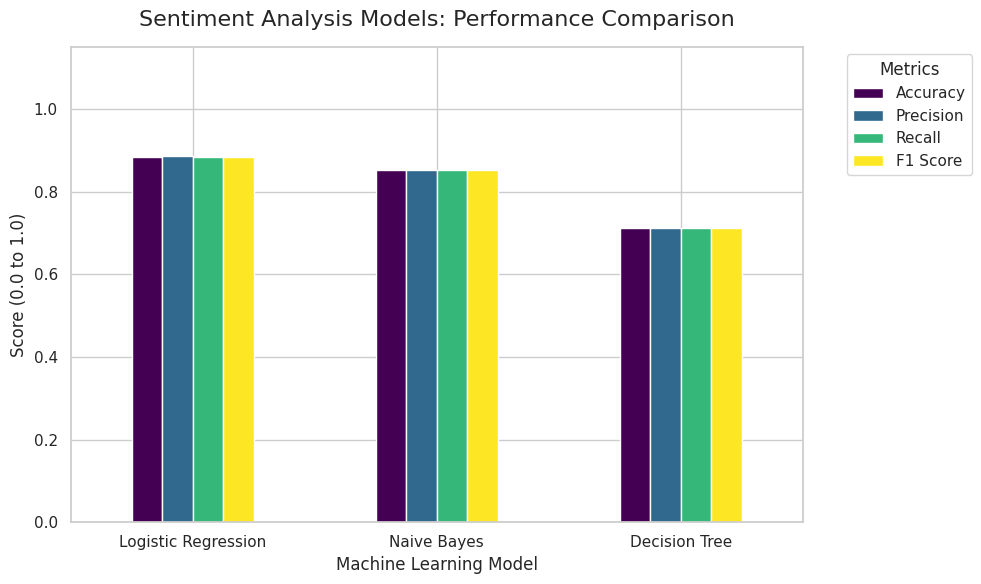

In [20]:
# Cell: Visualizing the Model Comparison
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating performance comparison chart...")

# Set the visual style
sns.set_theme(style="whitegrid")

# Plot the comparison DataFrame
# We set the 'Model' column as the index so the names appear on the bottom axis
ax = comparison_df.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')

# Add labels and title
plt.title('Sentiment Analysis Models: Performance Comparison', fontsize=16, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Machine Learning Model', fontsize=12)

# Rotate the model names on the X-axis so they are easy to read
plt.xticks(rotation=0)

# Set the Y-axis limit to slightly above 1.0 to make room for the legend
plt.ylim(0, 1.15)

# Move the legend outside the bars
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()